**Начало работы и анализ [настоящего датасета](./defefcts.csv) содержится в файле [MLdefectDataset](./MLdefectDataset.ipynb). В этом ноутбке представлена реализация обучения простенькой нейронной сети**

In [50]:
import pandas as pd
import numpy as np
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [51]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [52]:
batch_size = 32

In [53]:
df = pd.read_csv("defefcts.csv")

X, y = df.drop('defect', axis=1), df['defect']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

sc = StandardScaler()
X_train_std = (torch.from_numpy(sc.fit_transform(X_train).astype(np.float32))).to(device)
X_test_std = (torch.from_numpy(sc.transform(X_test).astype(np.float32))).to(device)
y_train_tensor = (torch.tensor(y_train.values, dtype=torch.float32)).to(device)
y_test_tensor = (torch.tensor(y_test.values, dtype=torch.float32)).to(device)

dataset = TensorDataset(X_train_std, y_train_tensor)

torch.manual_seed(1)
dataLoader = DataLoader(dataset, batch_size, shuffle=True)

In [54]:
inp_size = X_train_std.shape[1]

In [55]:
import torch.nn as nn

In [8]:
model_base = nn.Sequential(
    nn.Linear(inp_size, 20),
    nn.ReLU(),
    nn.Dropout(p=0.5),
    #nn.Linear(30, 5),
    #nn.ReLU(),
    #nn.Dropout(p=0.5),
    nn.Linear(20, 1),
    nn.Sigmoid()
).to(device)
loss_fn = nn.BCELoss()
optimizer = torch.optim.Adam(model_base.parameters(), weight_decay=1e-4)

In [56]:
from sklearn.metrics import roc_auc_score

In [57]:
num_epochs = 200
loss_hist_train = [0] * num_epochs
loss_hist_valid = [0] * num_epochs
roc_hist_train = [0] * num_epochs
roc_hist_valid = [0] * num_epochs

amount_batchs = len(dataLoader)

In [11]:
def train(model, num_epochs, train_dl, x_valid, y_valid):
    for epoch in range(num_epochs):
        model.train()
        for x_batch, y_batch in train_dl:
            pred = model(x_batch)[:, 0]
            loss = loss_fn(pred, y_batch)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            loss_hist_train[epoch] += loss.item()
            roc_hist_train[epoch] += roc_auc_score(y_batch.cpu().numpy(), pred.detach().cpu().numpy()) 
        loss_hist_train[epoch] /= amount_batchs
        roc_hist_train[epoch] /= amount_batchs

        model.eval()
        with torch.no_grad():
            y_pred = model(x_valid).detach().cpu().numpy().flatten()

        loss_hist_valid[epoch] = loss_fn(torch.tensor(y_pred).to(device), y_valid).item()
        roc_hist_valid[epoch] = roc_auc_score(y_valid.cpu().numpy(), y_pred)

In [12]:
train(model_base, num_epochs, dataLoader, X_test_std, y_test_tensor)

In [13]:
import matplotlib.pyplot as plt

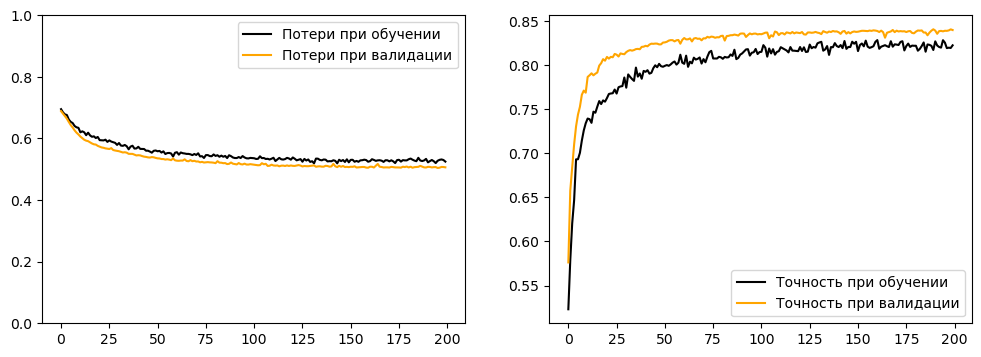

In [14]:
fig = plt.figure(figsize=(12, 4))
ax = fig.add_subplot(1,2 ,1)
plt.ylim([0.0, 1.0])
plt.plot(loss_hist_train, color='Black')
plt.plot(loss_hist_valid, color='Orange')
plt.legend(['Потери при обучении', 'Потери при валидации'])
ax = fig.add_subplot(1,2,2)
plt.plot(roc_hist_train, color='Black')
plt.plot(roc_hist_valid, color='orange')
plt.legend(['Точность при обучении', 'Точность при валидации'])
plt.show()

In [58]:
significant_features = ['nosi', 'cbo', 'dit', 'rfc']

X_train_significant = X_train[significant_features]
X_test_significant = X_test[significant_features]

sc_significant = StandardScaler()
X_train_std_sign = (torch.from_numpy(sc_significant.fit_transform(X_train_significant).astype(np.float32))).to(device)
X_test_std_sign = (torch.from_numpy(sc_significant.transform(X_test_significant).astype(np.float32))).to(device)

dataset_sign = TensorDataset(X_train_std_sign, y_train_tensor)

dataLoader_sign = DataLoader(dataset_sign, batch_size, shuffle=True)

inp_size = X_test_significant.shape[1]

In [66]:
model_sign = nn.Sequential(
    nn.Linear(inp_size, 5),
    nn.ReLU(),
    #nn.Dropout(p=0.25),
    #nn.Linear(5, 5),
    #nn.ReLU(),
    #nn.Dropout(p=0.25),
    nn.Linear(5, 1),
    nn.Sigmoid()
).to(device)

In [67]:
loss_hist_train = [0] * num_epochs
loss_hist_valid = [0] * num_epochs
roc_hist_train = [0] * num_epochs
roc_hist_valid = [0] * num_epochs

In [68]:
optimizer = torch.optim.Adam(model_base.parameters(), weight_decay=1e-4, lr=0.01)

In [69]:
train(model_sign, num_epochs, dataLoader_sign, X_test_std_sign, y_test_tensor)

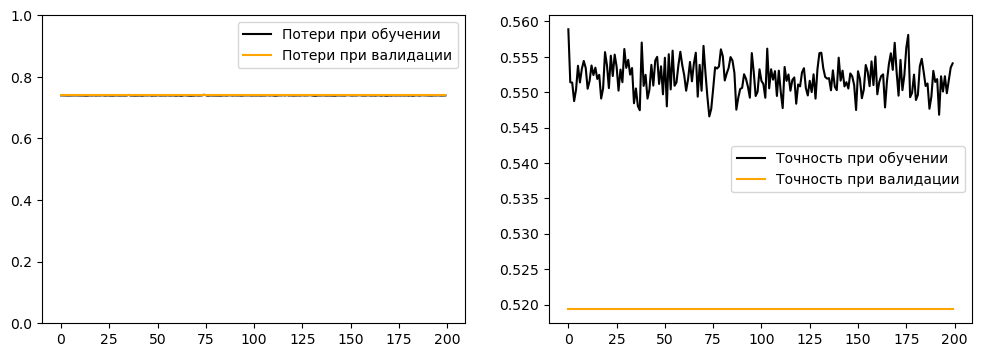

In [70]:
fig = plt.figure(figsize=(12, 4))
ax = fig.add_subplot(1,2 ,1)
plt.ylim([0.0, 1.0])
plt.plot(loss_hist_train, color='Black')
plt.plot(loss_hist_valid, color='Orange')
plt.legend(['Потери при обучении', 'Потери при валидации'])
ax = fig.add_subplot(1,2,2)
plt.plot(roc_hist_train, color='Black')
plt.plot(roc_hist_valid, color='orange')
plt.legend(['Точность при обучении', 'Точность при валидации'])
plt.show()

In [40]:
y_pred = model_sign(X_test_std_sign).detach().cpu().numpy().flatten()
roc_auc_score(y_test, y_pred)

0.5045424828277169

In [29]:
device

device(type='cuda')

In [44]:
for epoch in range(num_epochs):
        model_sign.train()
        for x_batch, y_batch in dataLoader_sign:
            pred = model_sign(x_batch)[:, 0]
            loss = loss_fn(pred, y_batch)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            loss_hist_train[epoch] += loss.item()
            roc_hist_train[epoch] += roc_auc_score(y_batch.cpu().numpy(), pred.detach().cpu().numpy()) 
        loss_hist_train[epoch] /= amount_batchs
        roc_hist_train[epoch] /= amount_batchs

        model_sign.eval()
        with torch.no_grad():
            y_pred = model_sign(X_test_std_sign).detach().cpu().numpy().flatten()

        loss_hist_valid[epoch] = loss_fn(torch.tensor(y_pred).to(device), y_test_tensor).item()
        roc_hist_valid[epoch] = roc_auc_score(y_test, y_pred)

In [47]:
roc_hist_valid

[0.4910157088638456,
 0.4910157088638456,
 0.4910157088638456,
 0.4910157088638456,
 0.4910157088638456,
 0.4910157088638456,
 0.4910157088638456,
 0.4910157088638456,
 0.4910157088638456,
 0.4910157088638456,
 0.4910157088638456,
 0.4910157088638456,
 0.4910157088638456,
 0.4910157088638456,
 0.4910157088638456,
 0.4910157088638456,
 0.4910157088638456,
 0.4910157088638456,
 0.4910157088638456,
 0.4910157088638456,
 0.4910157088638456,
 0.4910157088638456,
 0.4910157088638456,
 0.4910157088638456,
 0.4910157088638456,
 0.4910157088638456,
 0.4910157088638456,
 0.4910157088638456,
 0.4910157088638456,
 0.4910157088638456,
 0.4910157088638456,
 0.4910157088638456,
 0.4910157088638456,
 0.4910157088638456,
 0.4910157088638456,
 0.4910157088638456,
 0.4910157088638456,
 0.4910157088638456,
 0.4910157088638456,
 0.4910157088638456,
 0.4910157088638456,
 0.4910157088638456,
 0.4910157088638456,
 0.4910157088638456,
 0.4910157088638456,
 0.4910157088638456,
 0.4910157088638456,
 0.4910157088

In [60]:
def train_debug(model, num_epochs, train_dl, x_valid, y_valid):
    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0
        epoch_roc = 0
        
        for batch_idx, (x_batch, y_batch) in enumerate(train_dl):
            # Очищаем градиенты перед каждым батчем
            optimizer.zero_grad()
            
            pred = model(x_batch)[:, 0]
            loss = loss_fn(pred, y_batch)
            
            # Проверка градиентов
            loss.backward()
            
            # Проверка, есть ли градиенты
            total_grad = 0
            for param in model.parameters():
                if param.grad is not None:
                    total_grad += param.grad.abs().sum().item()
            
            optimizer.step()
            
            epoch_loss += loss.item()
            epoch_roc += roc_auc_score(y_batch.cpu().numpy(), pred.detach().cpu().numpy())
            
            # Отладка первых батчей
            if epoch == 0 and batch_idx < 5:
                print(f"  Батч {batch_idx}:")
                print(f"    Loss: {loss.item():.4f}")
                print(f"    Среднее предсказание: {pred.mean().item():.4f}")
                print(f"    Сумма градиентов: {total_grad:.4f}")
                print(f"    y_batch уникальные: {y_batch.unique().cpu().numpy()}")
        
        # Усредняем по эпохе
        loss_hist_train[epoch] = epoch_loss / len(train_dl)
        roc_hist_train[epoch] = epoch_roc / len(train_dl)
        
        # Валидация
        model.eval()
        with torch.no_grad():
            y_pred = model(x_valid).cpu().numpy().flatten()
        
        loss_hist_valid[epoch] = loss_fn(torch.tensor(y_pred).to(device), y_valid).item()
        roc_hist_valid[epoch] = roc_auc_score(y_valid.cpu().numpy(), y_pred)
        
        # Вывод прогресса
        if (epoch + 1) % 10 == 0:
            print(f"\nЭпоха {epoch+1}:")
            print(f"  Train Loss: {loss_hist_train[epoch]:.4f}")
            print(f"  Train ROC: {roc_hist_train[epoch]:.4f}")
            print(f"  Valid Loss: {loss_hist_valid[epoch]:.4f}")
            print(f"  Valid ROC: {roc_hist_valid[epoch]:.4f}")
            print(f"  Среднее предсказание на валидации: {y_pred.mean():.4f}")

In [61]:
train_debug(model_sign, num_epochs, dataLoader_sign, X_test_std_sign, y_test_tensor)

  Батч 0:
    Loss: 0.7477
    Среднее предсказание: 0.4241
    Сумма градиентов: 0.5504
    y_batch уникальные: [0. 1.]
  Батч 1:
    Loss: 0.6853
    Среднее предсказание: 0.4251
    Сумма градиентов: 0.6407
    y_batch уникальные: [0. 1.]
  Батч 2:
    Loss: 0.6697
    Среднее предсказание: 0.4273
    Сумма градиентов: 0.6276
    y_batch уникальные: [0. 1.]
  Батч 3:
    Loss: 0.6697
    Среднее предсказание: 0.4251
    Сумма градиентов: 0.5352
    y_batch уникальные: [0. 1.]
  Батч 4:
    Loss: 0.7143
    Среднее предсказание: 0.4255
    Сумма градиентов: 0.7846
    y_batch уникальные: [0. 1.]

Эпоха 10:
  Train Loss: 0.7092
  Train ROC: 0.3933
  Valid Loss: 0.7077
  Valid ROC: 0.3825
  Среднее предсказание на валидации: 0.4263

Эпоха 20:
  Train Loss: 0.7093
  Train ROC: 0.3932
  Valid Loss: 0.7077
  Valid ROC: 0.3825
  Среднее предсказание на валидации: 0.4263

Эпоха 30:
  Train Loss: 0.7086
  Train ROC: 0.3924
  Valid Loss: 0.7077
  Valid ROC: 0.3825
  Среднее предсказание на ва